# L3.2 — Multi-Layer Perceptron

Hands-on notebook for the lesson [`3-2-mlp.mdx`](../../llm-quest-theory/level-3/3-2-mlp.mdx).

> **Learning objectives**
> - Build a 2-layer MLP with `torch.nn.Module` and train it on XOR and `make_moons`.
> - See why a single neuron fails on XOR and what depth buys you.
> - Explore depth vs width empirically: which axis adds the most capacity per parameter?
> - Count parameters by hand and compare against `sum(p.numel())`.

## Connection to the theory
Covers **§1–§7** of the `.mdx`. This is the first notebook where we stop hand-rolling everything and start leaning on PyTorch.

In [1]:
# ---- Setup ----
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from sklearn.datasets import make_moons

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = "cpu"

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["figure.dpi"] = 100
%matplotlib inline
print("torch version:", torch.__version__)

torch version: 2.2.2


## 1. XOR — the classic "one neuron can't"
Four points where the label is the XOR of coordinates. A single neuron (one hyperplane) can never separate them.

In [2]:
X_xor = torch.tensor([[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]])
y_xor = torch.tensor([0.0, 1.0, 1.0, 0.0])

class SingleNeuron(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(2, 1)
    def forward(self, x):
        return self.linear(x).squeeze(-1)

class MLP2(nn.Module):
    def __init__(self, hidden=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

def train_bce(model, X, y, lr=0.3, n_steps=2000):
    opt  = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()
    losses = []
    for _ in range(n_steps):
        opt.zero_grad()
        logits = model(X)
        loss   = loss_fn(logits, y)
        loss.backward()
        opt.step()
        losses.append(loss.item())
    return losses

def accuracy(model, X, y):
    model.eval()
    with torch.no_grad():
        preds = (torch.sigmoid(model(X)) > 0.5).float()
    return (preds == y).float().mean().item()

neuron = SingleNeuron()
mlp    = MLP2(hidden=4)

losses_neuron = train_bce(neuron, X_xor, y_xor, lr=0.3, n_steps=2000)
losses_mlp    = train_bce(mlp,    X_xor, y_xor, lr=0.1, n_steps=2000)

print(f"single neuron accuracy on XOR: {accuracy(neuron, X_xor, y_xor):.2f}  (best possible: 0.75)")
print(f"2-layer MLP accuracy on XOR  : {accuracy(mlp,    X_xor, y_xor):.2f}")

single neuron accuracy on XOR: 0.50  (best possible: 0.75)
2-layer MLP accuracy on XOR  : 1.00


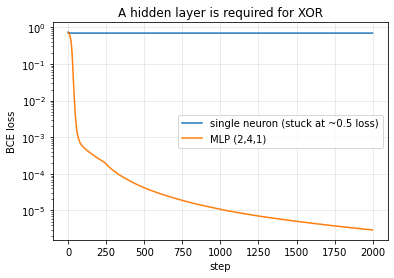

In [3]:
fig, ax = plt.subplots()
ax.plot(losses_neuron, label="single neuron (stuck at ~0.5 loss)")
ax.plot(losses_mlp,    label="MLP (2,4,1)")
ax.set_xlabel("step"); ax.set_ylabel("BCE loss")
ax.set_yscale("log"); ax.grid(alpha=0.3); ax.legend()
ax.set_title("A hidden layer is required for XOR")
plt.show()

## 2. Decision region — what does the MLP see?

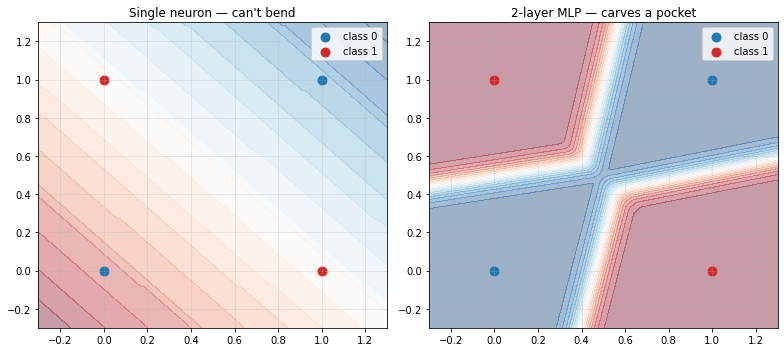

In [4]:
def plot_boundary(ax, model, X, y, title):
    model.eval()
    with torch.no_grad():
        xx, yy = np.meshgrid(np.linspace(-0.3, 1.3, 120), np.linspace(-0.3, 1.3, 120))
        grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
        probs = torch.sigmoid(model(grid)).numpy().reshape(xx.shape)
    ax.contourf(xx, yy, probs, levels=20, cmap="RdBu_r", alpha=0.4)
    ax.scatter(X[y == 0, 0], X[y == 0, 1], s=80, label="class 0", color="tab:blue")
    ax.scatter(X[y == 1, 0], X[y == 1, 1], s=80, label="class 1", color="tab:red")
    ax.set_title(title); ax.grid(alpha=0.3); ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
plot_boundary(axes[0], neuron, X_xor.numpy(), y_xor.numpy(), "Single neuron — can't bend")
plot_boundary(axes[1], mlp,    X_xor.numpy(), y_xor.numpy(), "2-layer MLP — carves a pocket")
plt.tight_layout(); plt.show()

## 3. `make_moons` — a real non-linear dataset

In [5]:
X_np, y_np = make_moons(n_samples=400, noise=0.2, random_state=SEED)
X_tr = torch.tensor(X_np, dtype=torch.float32)
y_tr = torch.tensor(y_np, dtype=torch.float32)

mlp_moons = MLP2(hidden=16)
loss_hist = train_bce(mlp_moons, X_tr, y_tr, lr=0.05, n_steps=1500)
print(f"train accuracy on moons: {accuracy(mlp_moons, X_tr, y_tr):.3f}")

train accuracy on moons: 0.978


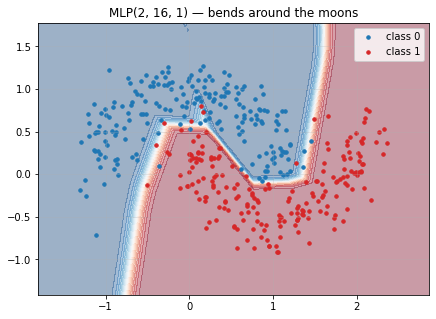

In [6]:
def plot_moons_boundary(ax, model, X, y, title):
    model.eval()
    with torch.no_grad():
        xx, yy = np.meshgrid(np.linspace(X[:, 0].min()-0.5, X[:, 0].max()+0.5, 150),
                             np.linspace(X[:, 1].min()-0.5, X[:, 1].max()+0.5, 150))
        grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
        probs = torch.sigmoid(model(grid)).numpy().reshape(xx.shape)
    ax.contourf(xx, yy, probs, levels=20, cmap="RdBu_r", alpha=0.4)
    ax.scatter(X[y == 0, 0], X[y == 0, 1], s=12, label="class 0", color="tab:blue")
    ax.scatter(X[y == 1, 0], X[y == 1, 1], s=12, label="class 1", color="tab:red")
    ax.set_title(title); ax.grid(alpha=0.3); ax.legend()

fig, ax = plt.subplots(figsize=(7, 5))
plot_moons_boundary(ax, mlp_moons, X_np, y_np, "MLP(2, 16, 1) — bends around the moons")
plt.show()

## 4. Depth vs width, at a matched parameter budget
A wider 1-hidden-layer network and a deeper 2-hidden-layer network with similar parameter counts. Which trains faster on moons?

Wide (1 hidden, 32): 129 params
Deep (2 hidden, 12): 205 params


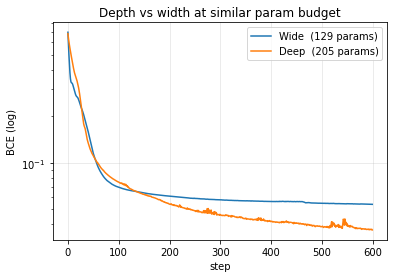

Wide accuracy: 0.973
Deep accuracy: 0.985


In [7]:
class Wide(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(2, hidden), nn.ReLU(),
                                 nn.Linear(hidden, 1))
    def forward(self, x): return self.net(x).squeeze(-1)

class Deep(nn.Module):
    def __init__(self, hidden=12):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 1),
        )
    def forward(self, x): return self.net(x).squeeze(-1)

def count_params(model):
    return sum(p.numel() for p in model.parameters())

wide = Wide(hidden=32)
deep = Deep(hidden=12)
print(f"Wide (1 hidden, 32): {count_params(wide)} params")
print(f"Deep (2 hidden, 12): {count_params(deep)} params")

torch.manual_seed(SEED)
wide = Wide(hidden=32); loss_wide = train_bce(wide, X_tr, y_tr, lr=0.05, n_steps=600)
torch.manual_seed(SEED)
deep = Deep(hidden=12); loss_deep = train_bce(deep, X_tr, y_tr, lr=0.05, n_steps=600)

fig, ax = plt.subplots()
ax.plot(loss_wide, label=f"Wide  ({count_params(Wide(32))} params)")
ax.plot(loss_deep, label=f"Deep  ({count_params(Deep(12))} params)")
ax.set_xlabel("step"); ax.set_ylabel("BCE (log)"); ax.set_yscale("log")
ax.grid(alpha=0.3); ax.legend(); ax.set_title("Depth vs width at similar param budget")
plt.show()

print(f"Wide accuracy: {accuracy(wide, X_tr, y_tr):.3f}")
print(f"Deep accuracy: {accuracy(deep, X_tr, y_tr):.3f}")

## 5. Parameter count by hand vs by PyTorch
The MNIST-shaped MLP from the lesson: 784 → 256 → 128 → 10.

In [8]:
class MnistMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 10),
        )
    def forward(self, x): return self.net(x)

mnist_mlp = MnistMLP()

# Hand count: (in*out + out) for each Linear
hand = (784 * 256 + 256) + (256 * 128 + 128) + (128 * 10 + 10)
torch_count = count_params(mnist_mlp)
print(f"hand-counted params : {hand:,}")
print(f"torch-counted params: {torch_count:,}")
print("match?              :", hand == torch_count)

hand-counted params : 235,146
torch-counted params: 235,146
match?              : True


## 6. Quick checks

In [9]:
assert accuracy(neuron, X_xor, y_xor) <= 0.75 + 1e-6, "single neuron on XOR ≤ 0.75"
assert accuracy(mlp,    X_xor, y_xor) == 1.0,         "MLP must solve XOR perfectly"
assert accuracy(mlp_moons, X_tr, y_tr) > 0.9,         "MLP should get > 90% on moons"
assert count_params(MnistMLP()) == 235_146,           "MNIST MLP should have 235,146 params"
print("OK — XOR needs depth, MLP handles moons, parameter count checks out.")

OK — XOR needs depth, MLP handles moons, parameter count checks out.


## Reflection questions

1. Single neuron + XOR caps at 75% accuracy. Why *exactly* 75% rather than 50%? (Hint: think about which 3 of the 4 points it can get right.)
2. The universal-approximation theorem says a single hidden layer is enough. Why does depth still win in practice?
3. If you halve the width of `Wide` but double the depth, the parameter count drops by roughly 2x but expressivity may grow. Try it and report.
4. In section 5 we assumed every weight matrix has a bias. What happens to the count if we set `bias=False` in one `Linear`? Verify empirically.

## References
- Source theory: [`3-2-mlp.mdx`](../../llm-quest-theory/level-3/3-2-mlp.mdx)
- Next: [`3-3-backprop`](3-3-backprop.ipynb)